ANNs are prone to overfitting due to their ability to handle higly complex data  
We can handle overfitting by:
- Adding more data
- Reduce complexity of architecture
- Early Stopping
- Regularization 
- `Dropouts`

## Dropout

Dropout is a regularization technique that, during each training iteration, randomly disables a subset of neurons from each layer.

Basically, we are removing some random neurons from original architecture in each iteration and training data on that new architecture.

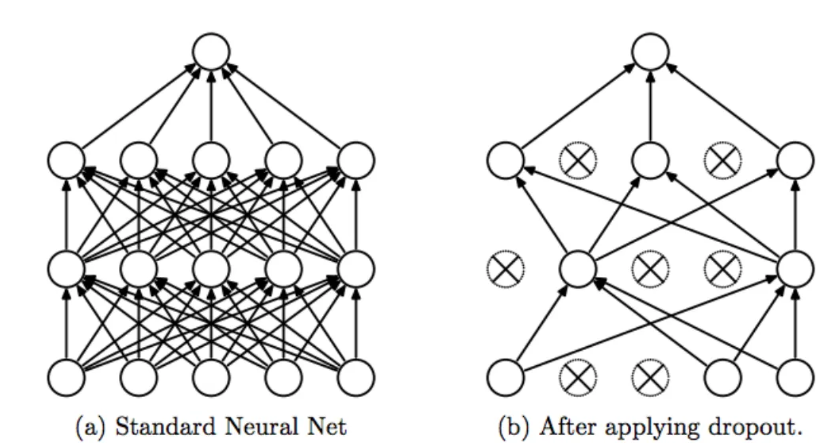

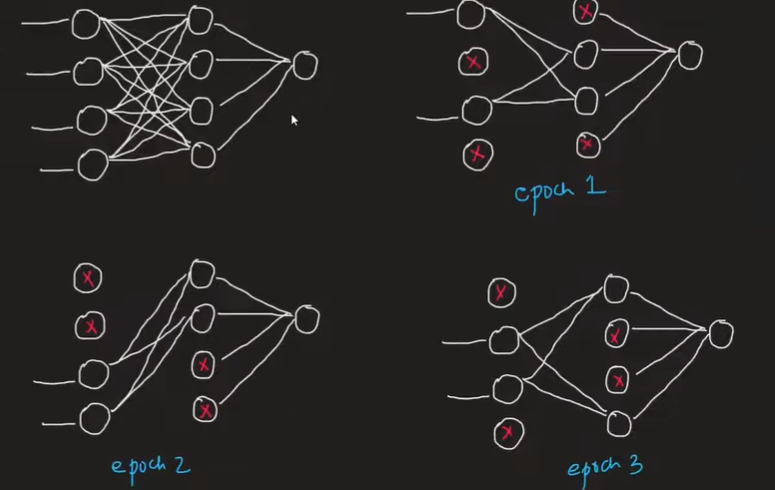

### Why this works?
1. The number of nodes are reduced --> complexity of architecutre reduced
2. We know each neuron captures some pattern, now lets say, there are some neurons that are capturing very minute details from data which is causing overfitting  
Now with dropout technique, we are removing those neurons in some iterations so that the neural network do not get as much dependent on those as before, i.e their weights and bias are not that significat as before

3. For each iteration we are training a unique architecture --> this makes model to focus on more robust patterns and not on minute details 


This is similar to ensemble learning. We are training many slightly different architectures on same data and then combining them.

### Training time
Dropout roughly doubles the number of iterations required to converge. However, training time for each epoch is less.

### How final weights are calculated?
- Dropout is only used during training, in prediction all the nodes are available in the architecture

- There is a parameter $p$ (probability) which decides the probability of each node to disable in each iteration during training

i.e $p$ = probability of a node to be disabled during training

- The final weight during prediction:  
if weight are completion of training is $w$ then   
$$ \text{weight for prediction} = w(1-p)$$


why?  
Because the weight was present only approx (1-p)% of times during training so we reduce its significance by (1-p) times

## Dropout Implementation in Regression problem

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from mlxtend.plotting import plot_decision_regions
from keras import Sequential
from keras.layers import Dense, Input, Dropout

In [3]:
X_train = np.linspace(-1, 1, 20)
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])


X_test = np.linspace(-1, 1, 20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

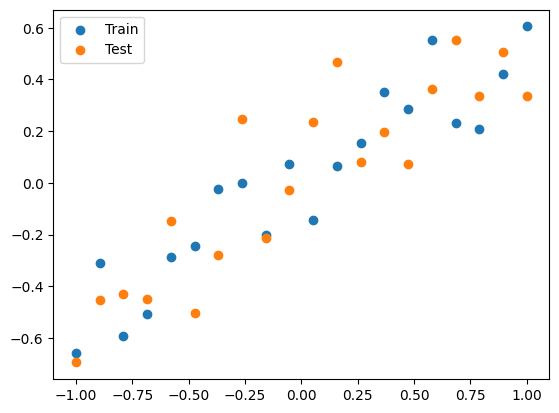

In [7]:
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label='Test')
plt.legend()

In [47]:
# Model without dropout
model_r1 = Sequential()

model_r1.add(Input(shape=(1,)))
model_r1.add(Dense(128, activation='relu'))
model_r1.add(Dense(128, activation='relu'))
model_r1.add(Dense(1, activation='linear'))

model_r1.compile(optimizer='Adam', loss='mse', metrics=['mse'])
#Taking so many epochs to get overfitting 
history_r1 = model_r1.fit(X_train, y_train, batch_size=X_train.shape[0],epochs=500,verbose=1,validation_data=(X_test, y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step - loss: 0.1667 - mse: 0.1667 - val_loss: 0.1505 - val_mse: 0.1505
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1371 - mse: 0.1371 - val_loss: 0.1251 - val_mse: 0.1251
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1120 - mse: 0.1120 - val_loss: 0.1040 - val_mse: 0.1040
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0912 - mse: 0.0912 - val_loss: 0.0864 - val_mse: 0.0864
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0738 - mse: 0.0738 - val_loss: 0.0718 - val_mse: 0.0718
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0594 - mse: 0.0594 - val_loss: 0.0601 - val_mse: 0.0601
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0478 - mse: 0.0478 - val_loss: 0.0508 - val_mse: 0.0508
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0386 - mse: 0.0386 - val_loss: 0.0437 - val_mse: 0.0437
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0315 - ms

In [51]:
#With dropout layers

model_r2 = Sequential()

model_r2.add(Input(shape=(1,)))
model_r2.add(Dense(128, activation='relu'))
model_r2.add(Dropout(rate=0.3))
model_r2.add(Dense(128, activation='relu'))
model_r2.add(Dropout(rate=0.3))
model_r2.add(Dense(1, activation='linear'))

model_r2.compile(optimizer='Adam', loss='mse', metrics=['mse'])
history_r2 = model_r2.fit(X_train, y_train, batch_size=X_train.shape[0],epochs=500,verbose=1,validation_data=(X_test, y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1211 - mse: 0.1211 - val_loss: 0.1017 - val_mse: 0.1017
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0884 - mse: 0.0884 - val_loss: 0.0831 - val_mse: 0.0831
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0652 - mse: 0.0652 - val_loss: 0.0676 - val_mse: 0.0676
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0684 - mse: 0.0684 - val_loss: 0.0553 - val_mse: 0.0553
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0416 - mse: 0.0416 - val_loss: 0.0457 - val_mse: 0.0457
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0487 - mse: 0.0487 - val_loss: 0.0386 - val_mse: 0.0386
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0373 - mse: 0.0373 - val_loss: 0.0338 - val_mse: 0.0338
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0392 - mse: 0.0392 - val_loss: 0.0312 - val_mse: 0.0312
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0259 - mse: 0

Overfitting is reduces a bit

In [61]:
model_r3 = Sequential()

model_r3.add(Input(shape=(1,)))
model_r3.add(Dense(128, activation='relu'))
model_r3.add(Dropout(rate=0.5))
model_r3.add(Dense(128, activation='relu'))
model_r3.add(Dropout(rate=0.5))
model_r3.add(Dense(1, activation='linear'))

model_r3.compile(optimizer='Adam', loss='mse', metrics=['mse'])
history_r3 = model_r3.fit(X_train, y_train, batch_size=X_train.shape[0],epochs=500,verbose=1,validation_data=(X_test, y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1147 - mse: 0.1147 - val_loss: 0.1135 - val_mse: 0.1135
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1175 - mse: 0.1175 - val_loss: 0.0997 - val_mse: 0.0997
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.1164 - mse: 0.1164 - val_loss: 0.0866 - val_mse: 0.0866
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0929 - mse: 0.0929 - val_loss: 0.0750 - val_mse: 0.0750
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0835 - mse: 0.0835 - val_loss: 0.0648 - val_mse: 0.0648
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0726 - mse: 0.0726 - val_loss: 0.0561 - val_mse: 0.0561
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0650 - mse: 0.0650 - val_loss: 0.0491 - val_mse: 0.0491
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0479 - mse: 0.0479 - val_loss: 0.0435 - val_mse: 0.0435
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0407 - mse

___All plots together___

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


[]

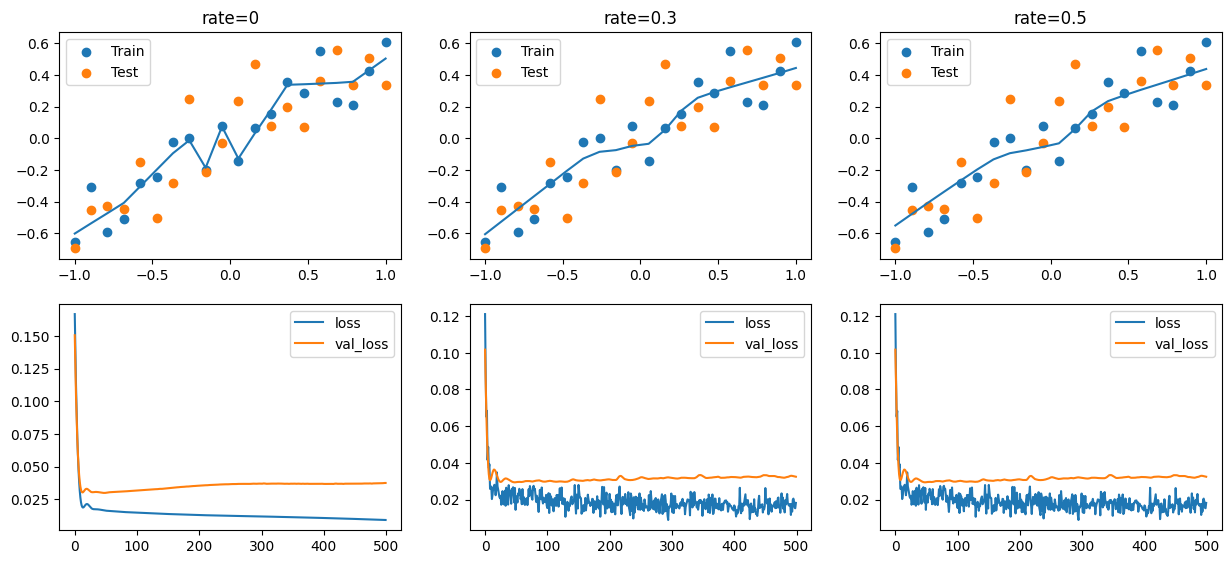

In [81]:
plt.figure(figsize=(15,10))

plt.subplot(3,3,1)
y_pred_r1 = model_r1.predict(X_test)
plt.title("rate=0")
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label='Test')
plt.plot(X_test, y_pred_r1)
plt.legend()

plt.subplot(3,3,4)
plt.plot(history_r1.history['loss'], label='loss')
plt.plot(history_r1.history['val_loss'],label='val_loss')
plt.legend()

plt.subplot(3,3,2)
y_pred_r2 = model_r2.predict(X_test)
plt.title("rate=0.3")
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label='Test')
plt.plot(X_test, y_pred_r2)
plt.legend()

plt.subplot(3,3,5)
plt.plot(history_r2.history['loss'], label='loss')
plt.plot(history_r2.history['val_loss'],label='val_loss')
plt.legend()

plt.subplot(3,3,3)
y_pred_r3 = model_r3.predict(X_test)
plt.title("rate=0.5")
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label='Test')
plt.plot(X_test, y_pred_r3)
plt.legend()

plt.subplot(3,3,6)
plt.plot(history_r2.history['loss'], label='loss')
plt.plot(history_r2.history['val_loss'],label='val_loss')
plt.legend()

plt.plot()

## Dropout Implementation on Classification problem

In [66]:
X = np.array([[-1.58986e-01,  4.23977e-01],
       [-3.47926e-01,  4.70760e-01],
       [-5.04608e-01,  3.53801e-01],
       [-5.96774e-01,  1.14035e-01],
       [-5.18433e-01, -1.72515e-01],
       [-2.92627e-01, -2.07602e-01],
       [-1.58986e-01, -4.38596e-02],
       [-5.76037e-02,  1.43275e-01],
       [-7.14286e-02,  2.71930e-01],
       [-2.97235e-01,  3.47953e-01],
       [-4.17051e-01,  2.01754e-01],
       [-4.40092e-01,  8.77193e-03],
       [-3.24885e-01, -3.21637e-02],
       [-2.46544e-01,  5.55556e-02],
       [-2.18894e-01,  2.01754e-01],
       [-3.43318e-01,  1.60819e-01],
       [-5.09217e-01,  7.89474e-02],
       [-3.84793e-01, -9.06433e-02],
       [-1.49770e-01,  1.25731e-01],
       [-1.95853e-01,  3.24561e-01],
       [-3.91705e-02, -2.19298e-01],
       [-1.08295e-01, -3.01170e-01],
       [-1.86636e-01, -3.30409e-01],
       [-2.18894e-01, -4.23977e-01],
       [-8.06452e-02, -5.64327e-01],
       [ 6.68203e-02, -5.17544e-01],
       [ 9.44700e-02, -3.24561e-01],
       [ 1.86636e-01, -1.66667e-01],
       [ 6.22120e-02, -7.30994e-02],
       [ 2.07373e-02, -1.95906e-01],
       [ 2.99539e-02, -3.42105e-01],
       [-9.90783e-02, -3.77193e-01],
       [-6.91244e-03, -4.64912e-01],
       [ 1.31336e-01, -4.29825e-01],
       [ 2.32719e-01, -1.95906e-01],
       [ 8.52535e-02, -8.47953e-02],
       [-1.31336e-01, -2.36842e-01],
       [ 2.30415e-03, -1.25731e-01],
       [ 1.22120e-01, -2.92398e-03],
       [-3.47926e-01, -3.12865e-01],
       [-2.28111e-01, -1.25731e-01],
       [-7.60369e-02,  1.46199e-02],
       [ 4.37788e-02,  2.04678e-02],
       [ 1.15207e-02,  1.54971e-01],
       [-4.17051e-01, -1.60819e-01],
       [-3.15668e-01, -3.18713e-01],
       [ 1.26728e-01, -2.19298e-01],
       [ 2.05069e-01, -3.12865e-01],
       [ 2.18894e-01, -4.59064e-01],
       [ 7.14286e-02, -6.46199e-01],
       [-1.31336e-01, -6.05263e-01],
       [-2.09677e-01, -5.81871e-01],
       [-2.28111e-01, -4.29825e-01],
       [-1.45161e-01, -4.12281e-01],
       [-6.68203e-02, -4.82456e-01],
       [ 1.35945e-01, -5.11696e-01],
       [ 2.69585e-01, -4.06433e-01],
       [ 2.97235e-01, -2.95322e-01],
       [ 2.74194e-01, -1.72515e-01],
       [ 2.55760e-01, -4.97076e-02],
       [ 2.23502e-01, -4.97076e-02],
       [ 1.82028e-01, -8.47953e-02],
       [ 1.58986e-01, -1.54971e-01],
       [ 7.14286e-02, -2.13450e-01],
       [ 1.61290e-02, -2.66082e-01],
       [-2.53456e-02, -3.83041e-01],
       [-1.15207e-02, -4.82456e-01],
       [-2.30415e-03, -5.05848e-01],
       [ 2.53456e-02, -5.11696e-01],
       [ 2.53456e-02, -5.58480e-01],
       [ 1.15207e-02, -6.57895e-01],
       [-4.83871e-02, -6.46199e-01],
       [-8.52535e-02, -5.52632e-01],
       [-9.90783e-02, -5.00000e-01],
       [-1.61290e-02, -4.23977e-01],
       [ 1.31336e-01, -3.59649e-01],
       [ 2.23502e-01, -3.71345e-01],
       [ 2.92627e-01, -3.01170e-01],
       [ 2.60369e-01, -2.07602e-01],
       [ 2.00461e-01, -2.25146e-01],
       [ 1.72811e-01, -2.71930e-01],
       [-1.31336e-01,  9.06433e-02],
       [-1.49770e-01,  7.30994e-02],
       [-2.41935e-01,  6.14035e-02],
       [-3.01843e-01,  1.78363e-01],
       [-2.97235e-01,  1.95906e-01],
       [-2.74194e-01,  3.07018e-01],
       [-3.24885e-01,  2.95322e-01],
       [-3.98618e-01,  2.66082e-01],
       [-4.35484e-01,  1.60819e-01],
       [-4.72350e-01,  7.89474e-02],
       [-3.38710e-01,  4.38596e-02],
       [-2.69585e-01,  4.38596e-02],
       [-2.55760e-01,  1.02339e-01],
       [-1.68203e-01,  2.66082e-01],
       [-1.12903e-01,  3.01170e-01],
       [-3.91705e-02,  3.47953e-01],
       [-1.26728e-01,  4.41520e-01],
       [-2.32719e-01,  4.41520e-01],
       [-3.38710e-01,  4.18129e-01],
       [-4.12442e-01,  3.53801e-01],
       [-5.09217e-01,  2.19298e-01],
       [-5.41475e-01,  1.46199e-02],
       [-5.04608e-01, -1.25731e-01],
       [-4.90783e-01, -1.43275e-01],
       [-3.61751e-01, -1.37427e-01],
       [-2.69585e-01, -8.47953e-02],
       [-2.23502e-01, -7.89474e-02],
       [-1.86636e-01, -3.80117e-02],
       [-1.54378e-01, -8.77193e-03],
       [-1.12903e-01,  5.55556e-02],
       [-8.52535e-02,  1.37427e-01],
       [-8.52535e-02,  2.77778e-01],
       [-1.68203e-01,  3.01170e-01],
       [-1.91244e-01,  1.95906e-01],
       [-1.40553e-01, -4.97076e-02],
       [-2.99539e-02,  6.72515e-02],
       [-2.00461e-01, -2.30994e-01],
       [-1.08295e-01, -8.47953e-02],
       [ 3.45622e-02,  6.72515e-02],
       [ 8.06452e-02,  1.19883e-01],
       [-3.85369e-01,  3.30409e-02],
       [-3.81221e-01,  1.31287e-01],
       [-3.52189e-01,  2.58187e-01],
       [-3.54263e-01,  3.64620e-01],
       [-4.14401e-01, -6.92982e-02],
       [-4.99424e-01, -3.24561e-02],
       [-2.98272e-01, -9.79532e-02],
       [-3.16935e-01, -1.83918e-01],
       [-3.68779e-01, -2.90351e-01],
       [-3.56336e-01, -3.96784e-01],
       [-2.71313e-01,  4.38596e-03],
       [-1.77995e-01,  8.62573e-02],
       [-2.46429e-01,  1.43567e-01],
       [-2.50576e-01,  2.29532e-01],
       [-2.21544e-01,  3.76901e-01],
       [-2.15323e-01,  2.95029e-01],
       [-1.30300e-01,  2.17251e-01],
       [-2.07028e-01,  2.89474e-02],
       [-9.71198e-02,  2.13158e-01],
       [-3.90553e-02,  2.58187e-01],
       [ 1.90092e-02,  4.01462e-01],
       [-3.69816e-02,  4.21930e-01],
       [-6.39401e-02,  3.31871e-01],
       [-1.30300e-01,  3.76901e-01],
       [-3.75000e-01, -4.37719e-01],
       [-3.95737e-01, -3.51754e-01],
       [-3.54263e-01, -2.08480e-01],
       [-4.37212e-01, -3.76316e-01],
       [-4.80760e-01, -5.03216e-01],
       [-4.10253e-01, -4.66374e-01],
       [-2.48502e-01, -2.57602e-01],
       [-2.27765e-01, -3.14912e-01],
       [-2.83756e-01, -3.84503e-01],
       [-2.92051e-01, -4.54094e-01],
       [-3.37673e-01, -5.19591e-01],
       [-2.77535e-01, -5.48246e-01],
       [-2.07028e-01, -5.35965e-01],
       [-1.86290e-01, -4.78655e-01],
       [-1.32373e-01, -5.07310e-01],
       [-1.77995e-01, -2.98538e-01],
       [-1.65553e-01, -1.75731e-01],
       [-1.61406e-01, -1.26608e-01],
       [ 3.45622e-04,  2.58187e-01],
       [ 7.91475e-02,  3.56433e-01],
       [-2.66129e-02,  1.80409e-01],
       [-5.35714e-02,  7.80702e-02],
       [-1.41705e-02, -5.29240e-02],
       [-7.01613e-02, -1.63450e-01],
       [-6.39401e-02, -2.94444e-01],
       [-3.07604e-02, -4.66374e-01],
       [-5.77189e-02, -5.27778e-01],
       [-5.35714e-02, -3.96784e-01],
       [ 5.21889e-02, -4.17251e-01],
       [-1.62442e-02, -1.67544e-01],
       [-6.39401e-02, -8.56725e-02],
       [-6.18664e-02, -1.60819e-02],
       [-3.80184e-03,  4.38596e-03],
       [ 4.18203e-02,  2.04971e-01],
       [ 7.91475e-02,  1.92690e-01],
       [ 4.59677e-02,  2.54094e-01],
       [ 1.18548e-01,  1.92690e-01],
       [ 1.10253e-01,  8.62573e-02],
       [ 1.08180e-01, -6.92982e-02],
       [ 1.66244e-01, -2.42690e-02],
       [ 1.41359e-01,  6.57895e-02],
       [ 1.43433e-01,  1.68129e-01],
       [ 1.70392e-01,  1.92690e-01],
       [ 1.08180e-01,  2.99123e-01],
       [ 1.18548e-01,  3.19591e-01],
       [ 1.26843e-01,  3.93275e-01],
       [-8.67512e-02,  4.21930e-01],
       [-4.73502e-02,  5.07895e-01],
       [ 2.52304e-02,  5.20175e-01],
       [ 6.25576e-02,  5.52924e-01],
       [-5.87558e-03,  4.42398e-01],
       [-5.14977e-02,  5.73392e-01],
       [-8.05300e-02,  5.07895e-01],
       [-1.53111e-01,  5.52924e-01],
       [-1.11636e-01,  5.48830e-01],
       [-1.63479e-01,  4.91520e-01],
       [-2.52650e-01, -1.88012e-01],
       [-2.46429e-01, -3.65497e-02],
       [-3.21083e-01, -4.33626e-01],
       [-3.31452e-01, -6.05556e-01],
       [-3.85369e-01, -5.15497e-01],
       [-3.99885e-01, -6.21930e-01],
       [-1.24078e-01, -1.26608e-01],
       [-3.16935e-01, -2.28947e-01],
       [-2.94124e-01, -1.34795e-01],
       [-1.53111e-01,  1.84503e-01]])

y = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 0.])

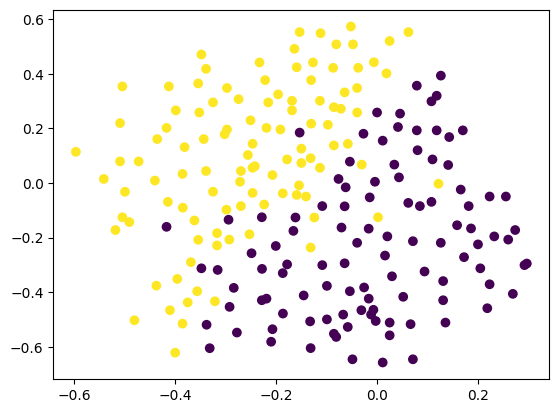

In [75]:
plt.scatter(X[:,0],X[:,1],c=y)

In [88]:
#Without dropout
model_c1 = Sequential()

model_c1.add(Input(shape=(2,)))
model_c1.add(Dense(128, activation='relu'))
model_c1.add(Dense(128, activation='relu'))
model_c1.add(Dense(1, activation='sigmoid'))

model_c1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['Accuracy'])
history_c1 = model_c1.fit(X, y, batch_size=X.shape[0],epochs=500,verbose=1,validation_split=0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - Accuracy: 0.5298 - loss: 0.6863 - val_Accuracy: 0.4186 - val_loss: 0.6850
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - Accuracy: 0.5238 - loss: 0.6780 - val_Accuracy: 0.5349 - val_loss: 0.6817
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - Accuracy: 0.7262 - loss: 0.6700 - val_Accuracy: 0.6047 - val_loss: 0.6786
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - Accuracy: 0.8333 - loss: 0.6623 - val_Accuracy: 0.6047 - val_loss: 0.6756
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - Accuracy: 0.8571 - loss: 0.6547 - val_Accuracy: 0.6047 - val_loss: 0.6726
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - Accuracy: 0.8571 - loss: 0.6472 - val_Accuracy: 0.6047 - val_loss: 0.6696
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - Accuracy: 0.8571 - loss: 0.6398 - val_Accuracy: 0.6047 - val_loss: 0.6667
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - Accuracy: 0.8571 - loss: 0.6325 - val_Accuracy: 0.6047 - val_

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 872us/step


<Axes: >

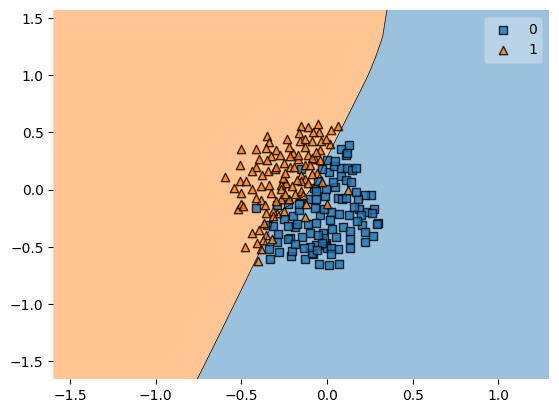

In [98]:
y = y.astype(int)

plot_decision_regions(X,y,clf=model_c1)

In [90]:
#With dropout
model_c2 = Sequential()

model_c2.add(Input(shape=(2,)))
model_c2.add(Dense(128, activation='relu'))
model_c2.add(Dropout(rate=0.5))
model_c2.add(Dense(128, activation='relu'))
model_c2.add(Dropout(rate=0.5))
model_c2.add(Dense(1, activation='sigmoid'))

model_c2.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['Accuracy'])
history_c2 = model_c2.fit(X, y, batch_size=X.shape[0],epochs=500,verbose=1,validation_split=0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - Accuracy: 0.4286 - loss: 0.6984 - val_Accuracy: 0.4884 - val_loss: 0.6936
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - Accuracy: 0.5298 - loss: 0.6897 - val_Accuracy: 0.7209 - val_loss: 0.6907
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - Accuracy: 0.6250 - loss: 0.6884 - val_Accuracy: 0.5814 - val_loss: 0.6877
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - Accuracy: 0.6488 - loss: 0.6795 - val_Accuracy: 0.5349 - val_loss: 0.6847
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - Accuracy: 0.6845 - loss: 0.6765 - val_Accuracy: 0.5581 - val_loss: 0.6817
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - Accuracy: 0.7500 - loss: 0.6667 - val_Accuracy: 0.6047 - val_loss: 0.6787
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - Accuracy: 0.7976 - loss: 0.6601 - val_Accuracy: 0.6047 - val_loss: 0.6757
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - Accuracy: 0.8155 - loss: 0.6554 - val_Accuracy: 0.6047 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 875us/step


<Axes: >

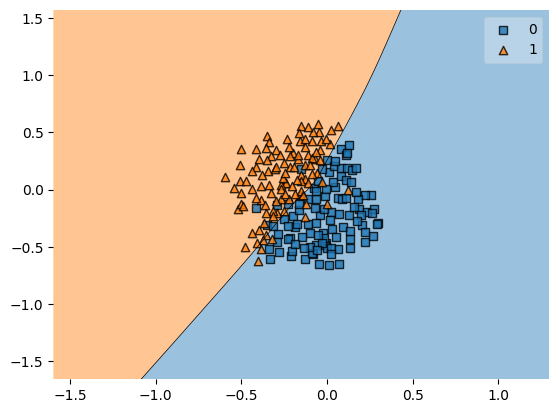

In [99]:
plot_decision_regions(X,y,clf=model_c2)

### Practical Tips
- If overfitting -> p↑
- If underfitting -> p↓
- Try to implement dropout on last layer intitially and see if results improve and then experiment with remaining layers
- Values of p for different neural networks for better results:
    - CNN -> 0.4-0.5
    - RNN -> 0.2-0.3
    - ANN -> 0.1-0.5